# NeuralCrew — Telco Customer Churn Midterm: EDA and Preprocessing

**Course:** ITAI 1374  
**Team:** Patrick Ray, Viviana Zamora, Funsho Orogun, Dustin Mastrota  
**Dataset:** [BlastChar Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Instructor dataset approval:** September 27, 2026 (per team proposal)

**Project goal:** Prepare the customer churn data for later supervised classification. This midterm documents data preparation and analysis, not trained model accuracy.

**Integration note:** This is a consolidated review copy based on the executed 70/30 preprocessing notebook submitted by Viviana and verified by Patrick, with a separately attributed comparison of Funsho's alternative notebook and Dustin's technical review. It does **not** claim that all three notebooks used the same preprocessing pipeline. Each member's original files should be preserved in the group repository.


## 1. Plan and data boundaries

1. Verify the file structure and unique identifiers, then create a fixed **70% training / 30% testing** split in Python.
2. Save the original records for both partitions. Set the testing partition aside before inspecting distributions.
3. Explore, clean, engineer features, encode, transform, scale, and demonstrate class balancing using **training data only**.
4. Export a readable clean training table, a numeric table at natural class prevalence, and a separate balanced training table.

The holdout is not explored, transformed, or evaluated in this notebook. Its label is used only to make a
stratified split, so both partitions represent the target proportion. Only a later final evaluation may use it.
All changes are implemented in Python; the source CSV remains unchanged. Run this notebook from top to bottom.


In [1]:
from pathlib import Path
import csv
import hashlib
import io
import json
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 42
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
COLORS = {0: "#286078", 1: "#de7958"}

def sha256_file(path):
    with Path(path).open("rb") as handle:
        return hashlib.file_digest(handle, "sha256").hexdigest()

RAW_FILENAME = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

def find_project_files():
    """Find the original CSV beside the notebook or in the original data/raw layout."""
    current = Path.cwd().resolve()
    for parent in [current, *current.parents]:
        for candidate in [parent, parent / "outputs" / "telco_churn_midterm"]:
            for raw_file in [candidate / RAW_FILENAME, candidate / "data" / "raw" / RAW_FILENAME]:
                if raw_file.is_file():
                    return candidate, raw_file
    raise FileNotFoundError(
        "Save WA_Fn-UseC_-Telco-Customer-Churn.csv in the same folder as this notebook "
        "(or in data/raw), then start Jupyter in that folder. The source is "
        "https://www.kaggle.com/datasets/blastchar/telco-customer-churn."
    )

PROJECT, RAW = find_project_files()
SPLITS = PROJECT / "data" / "splits"
PROCESSED = PROJECT / "data" / "processed"
REPORTS = PROJECT / "reports"
for directory in [SPLITS, PROCESSED, REPORTS]:
    directory.mkdir(parents=True, exist_ok=True)

def save_plot(fig, name):
    fig.savefig(REPORTS / name, dpi=140, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

print("Project folder located; all saved files use paths relative to this folder.")
print("Python", platform.python_version(), "| pandas", pd.__version__, "| NumPy", np.__version__)


Project folder located; all saved files use paths relative to this folder.
Python 3.13.16 | pandas 2.2.3 | NumPy 2.1.3


## 2. Verify structure before splitting

At this stage we check only file structure, record count, the target needed for stratification,
and identifier uniqueness. We do not calculate feature statistics or plot the full dataset.
The file is read as text first so the exact original rows can be preserved in the split files.


In [2]:
source_hash_before = sha256_file(RAW)
source_bytes = RAW.read_bytes()
original_lines = source_bytes.splitlines(keepends=True)
parsed_rows = list(csv.reader(io.StringIO(source_bytes.decode("utf-8-sig"), newline="")))
header, original_rows = parsed_rows[0], parsed_rows[1:]
original_row_count = len(original_rows)

assert len(header) == len(set(header)), "Duplicate column names require investigation."
assert "customerID" in header and "Churn" in header
assert original_row_count >= 2000, "The assignment normally requires at least 2,000 rows."
assert all(len(row) == len(header) for row in original_rows), "Malformed CSV record."
assert len(original_lines) == original_row_count + 1, "This exact-line exporter expects one record per line."

id_position, target_position = header.index("customerID"), header.index("Churn")
record_ids = [row[id_position] for row in original_rows]
assert all(identifier.strip() for identifier in record_ids), "Missing ID."
assert len(set(record_ids)) == original_row_count, "Duplicate original customer IDs require review."
stratification_labels = np.array([row[target_position].strip() for row in original_rows])
assert set(stratification_labels) == {"No", "Yes"}, "Unexpected target labels."
print(f"Structure validated: {original_row_count:,} records and {len(header)} columns; IDs are unique.")
print("Column names:", header)


Structure validated: 7,043 records and 21 columns; IDs are unique.
Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 3. Create and seal the 70/30 split

NumPy's random generator with seed 42 makes row selection reproducible. The function below allocates
the test total across the two target classes as proportionally as whole rows allow. It first floors
the desired class counts, then assigns the remaining test slots to the largest fractional remainders.
This is **stratified random splitting in Python**, performed before any exploratory analysis.

The test total is rounded up because a fractional customer is impossible. The split files preserve each
selected source record, including blank values, exactly as stored in the source. After checking disjoint
identifiers, we discard full-dataset and holdout row objects. File hashes verify integrity without test-set EDA.


In [3]:
def stratified_split_indices(labels, test_fraction=0.30, seed=42):
    """Split row indices, allocating test rows proportionally by target class."""
    labels = np.asarray(labels)
    classes, counts = np.unique(labels, return_counts=True)
    test_total = int(np.ceil(len(labels) * test_fraction))
    desired = counts * test_total / len(labels)
    allocations = np.floor(desired).astype(int)
    remainder_order = np.argsort(-(desired - allocations), kind="stable")
    for position in remainder_order[:test_total - allocations.sum()]:
        allocations[position] += 1
    assert ((allocations > 0) & (allocations < counts)).all(), "Classes need enough rows in both partitions."
    rng = np.random.default_rng(seed)
    training, testing = [], []
    for label, test_count in zip(classes, allocations):
        indices = rng.permutation(np.flatnonzero(labels == label))
        testing.extend(indices[:test_count])
        training.extend(indices[test_count:])
    return np.sort(np.array(training)), np.sort(np.array(testing))

train_indices, holdout_indices = stratified_split_indices(stratification_labels, 0.30, SEED)
train_id_set = {record_ids[i] for i in train_indices}
holdout_id_set = {record_ids[i] for i in holdout_indices}
assert train_id_set.isdisjoint(holdout_id_set)
assert len(train_indices) + len(holdout_indices) == original_row_count
assert len(holdout_indices) == int(np.ceil(0.30 * original_row_count))
split_counts = {"train": int(len(train_indices)), "holdout": int(len(holdout_indices))}
split_id_disjoint = True

def write_original_rows(destination, selected_indices):
    with destination.open("wb") as handle:
        handle.write(original_lines[0])
        for index in selected_indices:
            handle.write(original_lines[int(index) + 1])

TRAIN_RAW = SPLITS / "train_raw.csv"
HOLDOUT_RAW = SPLITS / "test_holdout_raw.csv"
write_original_rows(TRAIN_RAW, train_indices)
write_original_rows(HOLDOUT_RAW, holdout_indices)
train_hash_before = sha256_file(TRAIN_RAW)
holdout_hash_before = sha256_file(HOLDOUT_RAW)

del source_bytes, original_lines, parsed_rows, original_rows
del record_ids, stratification_labels, train_indices, holdout_indices
del train_id_set, holdout_id_set
print(f"Training: {split_counts['train']:,} rows ({split_counts['train']/original_row_count:.2%})")
print(f"Untouched testing: {split_counts['holdout']:,} rows ({split_counts['holdout']/original_row_count:.2%})")
print("Identifier overlap: 0. Only the training CSV will be loaded below.")


Training: 4,930 rows (70.00%)
Untouched testing: 2,113 rows (30.00%)
Identifier overlap: 0. Only the training CSV will be loaded below.


## 4. Training-only inspection

Read every training value as text first to make blank strings visible. An exact duplicate includes
the customer ID; identical feature profiles can legitimately belong to different people and are retained.


In [4]:
train_raw = pd.read_csv(TRAIN_RAW, dtype=str, keep_default_na=False)
assert len(train_raw) == split_counts["train"]
assert train_raw["customerID"].is_unique
exact_duplicate_count = int(train_raw.duplicated().sum())
duplicate_profile_count = int(train_raw.drop(columns=["customerID"]).duplicated().sum())
raw_blank_counts = train_raw.apply(lambda column: column.str.strip().eq("").sum()).astype(int)
print("Training-only sample, before processing:")
display(train_raw.head(6))
print("Exact duplicate training records:", exact_duplicate_count)
print("Repeated profiles excluding ID (retained as separate customers):", duplicate_profile_count)
print("Blank/whitespace-only values by column:")
display(raw_blank_counts.to_frame("blank_count").T)


Training-only sample, before processing:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes


Exact duplicate training records: 0
Repeated profiles excluding ID (retained as separate customers): 11
Blank/whitespace-only values by column:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
blank_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0


In [5]:
numeric_columns = ["tenure", "MonthlyCharges", "TotalCharges"]
train = train_raw.copy()
for column in train.columns:
    train[column] = train[column].str.strip()

invalid_numeric_counts = {}
negative_numeric_counts = {}
for column in numeric_columns:
    original = train[column]
    numeric = pd.to_numeric(original.replace("", np.nan), errors="coerce")
    invalid_numeric_counts[column] = int((original.ne("") & numeric.isna()).sum())
    negative_numeric_counts[column] = int(numeric.lt(0).sum())
    # Negative tenure/charges are invalid in this educational dataset's definitions.
    # Record the count, then mark them missing; imputation is learned from training only.
    train[column] = numeric.mask(numeric.lt(0), np.nan)

assert set(train["SeniorCitizen"]) <= {"0", "1"}, "Unexpected SeniorCitizen code."
train["SeniorCitizen"] = train["SeniorCitizen"].astype(int)
assert set(train["Churn"]) == {"No", "Yes"}
target = train["Churn"].map({"No": 0, "Yes": 1}).astype(int)
class_counts_before = target.value_counts().sort_index()
categorical_columns = [column for column in train.columns
                       if column not in ["customerID", "Churn", "SeniorCitizen", *numeric_columns]]
categorical_blank_counts = {}
for column in categorical_columns:
    categorical_blank_counts[column] = int(train[column].eq("").sum())
    train[column] = train[column].replace("", "Unknown")

numeric_before = train[numeric_columns].copy()
numeric_missing_before = numeric_before.isna().sum().astype(int)
print("Unparseable nonblank numeric values:", invalid_numeric_counts)
print("Negative numeric values treated as missing:", negative_numeric_counts)
print("Training numeric summary before imputation:")
display(numeric_before.describe().round(2))
print("Training target counts (0 = stays, 1 = churns):")
display(class_counts_before.to_frame("customers"))
print(f"Observed training churn rate: {target.mean():.2%}.")


Unparseable nonblank numeric values: {'tenure': 0, 'MonthlyCharges': 0, 'TotalCharges': 0}
Negative numeric values treated as missing: {'tenure': 0, 'MonthlyCharges': 0, 'TotalCharges': 0}
Training numeric summary before imputation:


,tenure,MonthlyCharges,TotalCharges
count,4930.00,4930.00,4922.00
mean,32.60,64.61,2305.15
std,24.66,30.28,2288.53
min,0.00,18.25,18.85
25%,9.00,34.80,404.66
50%,29.00,70.30,1415.28
75%,56.00,90.00,3876.00
max,72.00,118.75,8684.80


Training target counts (0 = stays, 1 = churns):


,customers
Churn,
0,3622
1,1308


Observed training churn rate: 26.53%.


## 5. Missing values and data quality

The raw `TotalCharges` field can contain spaces. Converting it to numeric reveals those entries as missing.
We use the **training median** instead of assuming an unknown amount must be zero. A separate missingness
indicator retains the fact that the value was absent. Blank categorical fields, if present, receive the explicit
`Unknown` category. Values such as `No internet service` and `No phone service` describe real service states
and remain distinct categories. No customers are deleted because their feature profiles match.

Large charges or long tenure are not automatically errors. We inspect their distributions rather than
remove valid customers using an arbitrary outlier cutoff.


In [6]:
clean = train.copy()
clean["TotalCharges_missing"] = clean["TotalCharges"].isna().astype(int)
training_medians = clean[numeric_columns].median()
assert training_medians.notna().all(), "An entirely missing numeric column needs a separate decision."
clean[numeric_columns] = clean[numeric_columns].fillna(training_medians)
imputation_values = {column: float(value) for column, value in training_medians.items()}
assert clean[numeric_columns].notna().all().all()
assert np.isfinite(clean[numeric_columns].to_numpy()).all()

print("Medians learned from training rows only:", imputation_values)
affected = train["TotalCharges"].isna()
print(f"TotalCharges imputed in {int(affected.sum())} training records.")
if affected.any():
    display(pd.DataFrame({
        "customerID": clean.loc[affected, "customerID"],
        "tenure": train.loc[affected, "tenure"],
        "TotalCharges_before": train.loc[affected, "TotalCharges"],
        "TotalCharges_after": clean.loc[affected, "TotalCharges"],
        "missing_indicator": clean.loc[affected, "TotalCharges_missing"],
    }).head(10))
else:
    print("This split has no missing TotalCharges values; the same rule is still reproducible.")
print("Cleaned training sample:")
display(clean.head(6))


Medians learned from training rows only: {'tenure': 29.0, 'MonthlyCharges': 70.3, 'TotalCharges': 1415.275}
TotalCharges imputed in 8 training records.


,customerID,tenure,TotalCharges_before,TotalCharges_after,missing_indicator
527,3115-CZMZD,0,NaN,1415.275,1
767,4367-NUYAO,0,NaN,1415.275,1
958,1371-DWPAZ,0,NaN,1415.275,1
2329,7644-OMVMY,0,NaN,1415.275,1
2677,3213-VVOLG,0,NaN,1415.275,1
3080,2520-SGTTA,0,NaN,1415.275,1
4667,4075-WKNIU,0,NaN,1415.275,1
4727,2775-SEFEE,0,NaN,1415.275,1


Cleaned training sample:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_missing
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,0


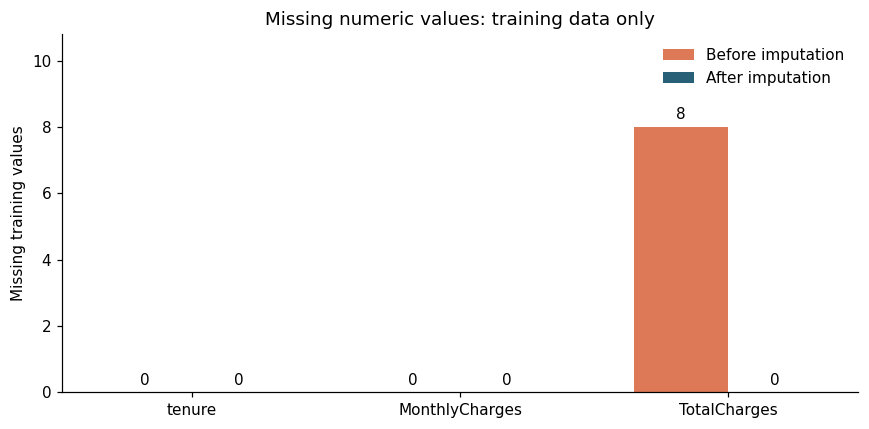

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
positions = np.arange(len(numeric_columns))
width = 0.35
bars_before = ax.bar(positions - width/2, numeric_missing_before, width,
                     label="Before imputation", color="#de7958")
bars_after = ax.bar(positions + width/2, clean[numeric_columns].isna().sum(), width,
                    label="After imputation", color="#286078")
ax.bar_label(bars_before, padding=3)
ax.bar_label(bars_after, padding=3)
ax.set_xticks(positions, numeric_columns)
ax.set_ylabel("Missing training values")
ax.set_title("Missing numeric values: training data only")
ax.set_ylim(0, max(1, numeric_missing_before.max()) * 1.35)
ax.legend(frameon=False)
fig.tight_layout()
save_plot(fig, "01_missing_values.png")


## 6. Training patterns relevant to the ML question

Churn rates below are descriptive associations in training data. They do not establish that a contract
causes churn or that an intervention will change behavior. Sample sizes accompany rates because small groups
can produce unstable estimates. These patterns may suggest useful predictors for the later classification task.


Training churn by contract type:


,customers,churn_rate,churn_rate_percent
Contract,,,
Month-to-month,2708,0.426883,42.69
One year,1013,0.119447,11.94
Two year,1209,0.025641,2.56


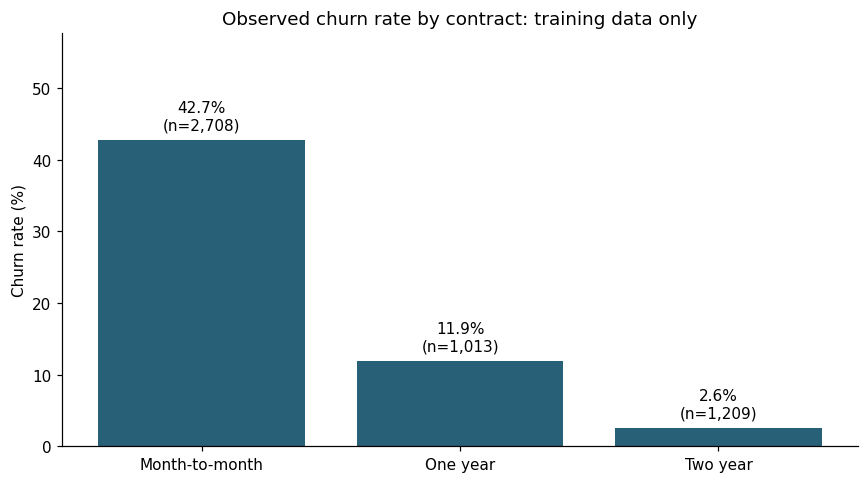

Training association: Month-to-month has the highest observed churn rate (42.7%); Two year has the lowest (2.6%). This is not a causal claim.


In [8]:
contract_summary = (clean.assign(churn_numeric=target)
                    .groupby("Contract")["churn_numeric"]
                    .agg(customers="size", churn_rate="mean")
                    .sort_values("churn_rate", ascending=False))
print("Training churn by contract type:")
display(contract_summary.assign(churn_rate_percent=(100 * contract_summary["churn_rate"]).round(2)))
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(contract_summary.index, 100 * contract_summary["churn_rate"], color="#286078")
ax.bar_label(bars, labels=[f"{rate:.1%}\n(n={count:,})" for rate, count in
                         zip(contract_summary["churn_rate"], contract_summary["customers"])], padding=5)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Observed churn rate by contract: training data only")
ax.set_ylim(0, max(10, 100 * contract_summary["churn_rate"].max()) * 1.35)
fig.tight_layout()
save_plot(fig, "02_contract_churn.png")
highest_group = contract_summary.index[0]
lowest_group = contract_summary.index[-1]
print(f"Training association: {highest_group} has the highest observed churn rate "
      f"({contract_summary.iloc[0]['churn_rate']:.1%}); {lowest_group} has the lowest "
      f"({contract_summary.iloc[-1]['churn_rate']:.1%}). This is not a causal claim.")


## 7. Feature engineering

Create features from information already present in a customer's record:

- `has_internet`: whether `InternetService` is DSL or Fiber optic.
- `total_services`: count of nine subscribed service flags, including phone and internet. A `Yes`
  response counts as one; `No internet service` and `No phone service` count as zero for this count only.
- `is_new_customer`: tenure of **12 months or less**, using a fixed, transparent threshold.
- `TotalCharges_missing`: already created before imputation.

These features contain no target information. They overlap with existing predictors, so their incremental
value should be tested in cross-validation. The supplied dataset is a snapshot: the eventual prediction
time and availability of each feature must be defined before applying a model to a real business workflow.


In [9]:
clean["has_internet"] = clean["InternetService"].isin(["DSL", "Fiber optic"]).astype(int)
service_yes_columns = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
                       "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
clean["total_services"] = clean[service_yes_columns].eq("Yes").sum(axis=1) + clean["has_internet"]
clean["is_new_customer"] = clean["tenure"].le(12).astype(int)
assert clean["total_services"].between(0, 9).all()
print("Example engineered features (training data):")
display(clean[["customerID", "tenure", "InternetService", "has_internet",
               "total_services", "is_new_customer", "TotalCharges_missing"]].head(8))
print("Training feature counts:")
display(clean[["has_internet", "total_services", "is_new_customer", "TotalCharges_missing"]].describe().round(2))


Example engineered features (training data):


,customerID,tenure,InternetService,has_internet,total_services,is_new_customer,TotalCharges_missing
0,7590-VHVEG,1,DSL,1,2,1,0
1,5575-GNVDE,34,DSL,1,4,0,0
2,3668-QPYBK,2,DSL,1,4,1,0
3,7795-CFOCW,45,DSL,1,4,0,0
4,9237-HQITU,2,Fiber optic,1,2,1,0
5,9305-CDSKC,8,Fiber optic,1,6,1,0
6,1452-KIOVK,22,Fiber optic,1,5,0,0
7,6388-TABGU,62,DSL,1,4,0,0


Training feature counts:


,has_internet,total_services,is_new_customer,TotalCharges_missing
count,4930.00,4930.00,4930.00,4930.00
mean,0.78,4.14,0.31,0.00
std,0.41,2.33,0.46,0.04
min,0.00,1.00,0.00,0.00
25%,1.00,2.00,0.00,0.00
50%,1.00,4.00,0.00,0.00
75%,1.00,6.00,1.00,0.00
max,1.00,9.00,1.00,1.00


## 8. Encode, reshape, and scale

Encode `Churn` as 0 = No and 1 = Yes. Keep `customerID` only as record metadata.
Use pandas `get_dummies` to one-hot encode categorical predictors. Record the training categories and
resulting column order so future data can be reindexed to these columns, with zeros for unseen categories.
Future evaluation must not add categories or change fitted values based on the test data.

Scale tenure, monthly charges, and service count to training mean 0 and population standard deviation 1.
For total charges, apply a **square-root transformation** before the same standard scaling. This fixed,
transparent transformation compresses high nonnegative charges and illustrates distribution reshaping
(often called normalization in assignments) separately from scaling. It **does not guarantee a normal
distribution** or improved prediction. Keep binary flags as 0/1. All medians, means, standard deviations,
and category sets are learned from training rows only.


In [10]:
standard_columns = ["tenure", "MonthlyCharges", "total_services"]
power_columns = ["TotalCharges"]
binary_columns = ["SeniorCitizen", "TotalCharges_missing", "has_internet", "is_new_customer"]
feature_columns = standard_columns + power_columns + binary_columns + categorical_columns
assert "customerID" not in feature_columns and "Churn" not in feature_columns
assert len(feature_columns) == len(set(feature_columns))

# Square-root reshaping is defined only for nonnegative amounts.
assert clean["TotalCharges"].ge(0).all()
numeric_for_scaling = clean[standard_columns + power_columns].astype(float).copy()
numeric_for_scaling["TotalCharges"] = np.sqrt(numeric_for_scaling["TotalCharges"])
scaling_means = numeric_for_scaling.mean()
scaling_scales = numeric_for_scaling.std(ddof=0)
constant_numeric_columns = scaling_scales[scaling_scales.eq(0)].index.tolist()
scaling_scales = scaling_scales.mask(scaling_scales.eq(0), 1.0)
scaled = (numeric_for_scaling - scaling_means) / scaling_scales

category_levels = {column: sorted(clean[column].unique().tolist()) for column in categorical_columns}
one_hot = pd.get_dummies(clean[categorical_columns], columns=categorical_columns, dtype=float)
one_hot_columns = one_hot.columns.tolist()
X_encoded = pd.concat([scaled, clean[binary_columns].astype(float), one_hot], axis=1)
encoded_feature_names = X_encoded.columns.tolist()
assert X_encoded.columns.is_unique
assert X_encoded.notna().all().all() and np.isfinite(X_encoded.to_numpy()).all()
assert not any("customerID" in name or "Churn" in name for name in encoded_feature_names)
print(f"{len(feature_columns)} input predictors become {X_encoded.shape[1]} numeric predictors, "
      f"including {len(one_hot_columns)} one-hot columns.")
print("Numeric model-input sample (ID and target excluded):")
display(X_encoded.head(5).round(3))


23 input predictors become 49 numeric predictors, including 41 one-hot columns.
Numeric model-input sample (ID and target excluded):


,tenure,MonthlyCharges,total_services,TotalCharges,SeniorCitizen,TotalCharges_missing,has_internet,is_new_customer,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,...,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-1.282,-1.148,-0.919,-1.447,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.057,-0.253,-0.060,0.093,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-1.241,-0.355,-0.060,-1.247,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.503,-0.737,-0.060,0.070,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,-1.241,0.201,-0.919,-1.169,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## 9. Compare numeric distributions before and after

The left-hand plots use training values before imputation (missing values are omitted by the histogram).
The right-hand plots show corresponding transformed model inputs, including imputed rows.
Standard scaling changes units, not distribution shape. The square root changes total charges' shape;
we calculate skewness on the same imputed rows before and after reshaping for a fair comparison.


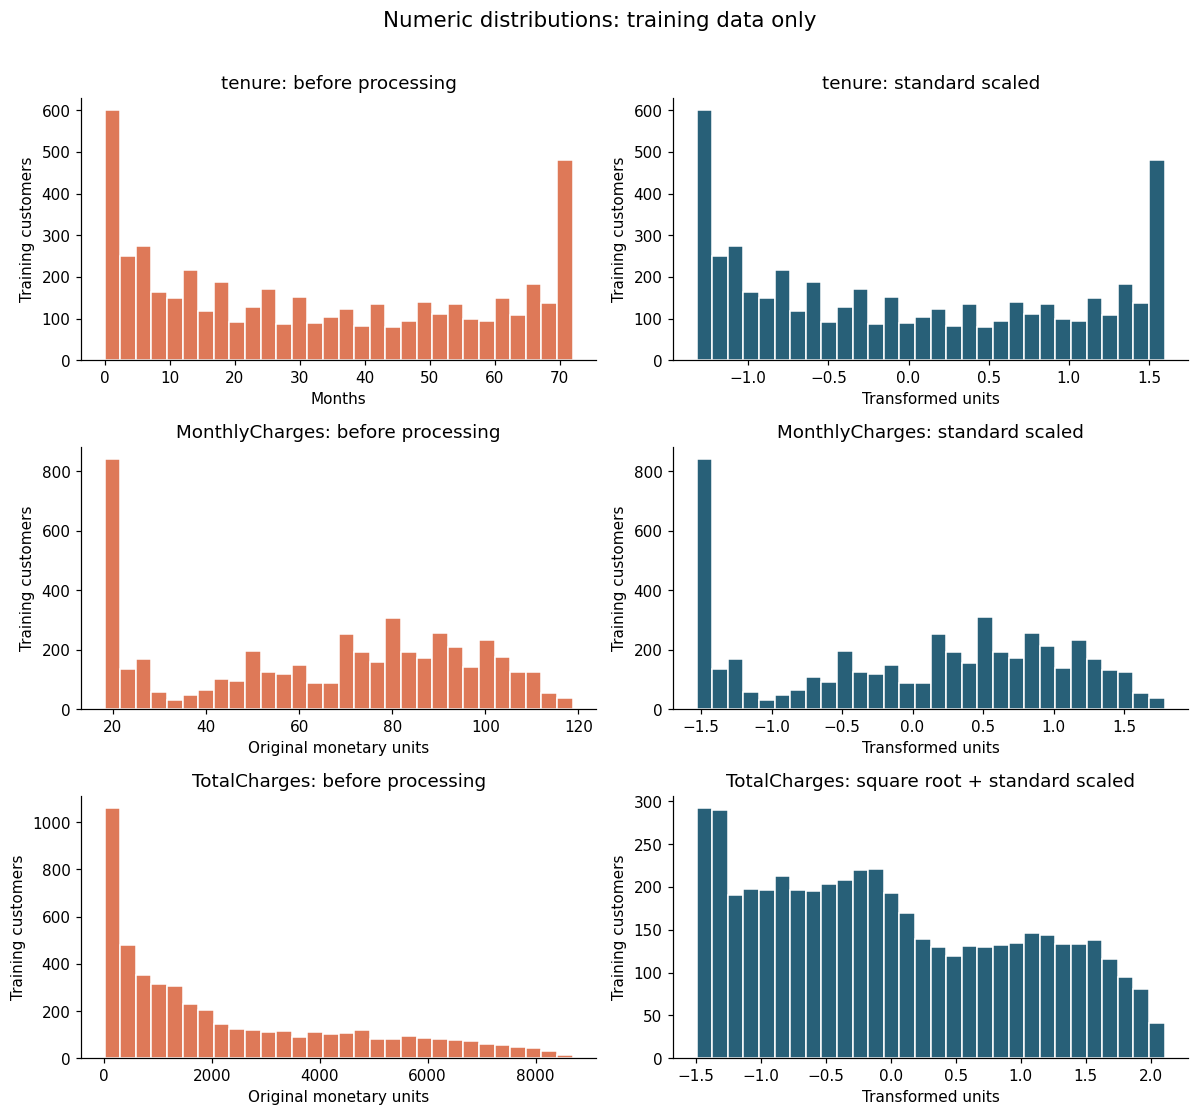

TotalCharges sample skewness on the same imputed training rows: 0.954 -> 0.306.
Absolute skewness decreased.
This observation alone does not establish normality or better prediction.
Scaled training means / population standard deviations:


,mean,std_ddof_0
tenure,-0.0,1.0
MonthlyCharges,0.0,1.0
total_services,0.0,1.0
TotalCharges,-0.0,1.0


In [11]:
fig, axes = plt.subplots(3, 2, figsize=(11, 10))
after_labels = {"tenure": "standard scaled", "MonthlyCharges": "standard scaled",
                "TotalCharges": "square root + standard scaled"}
for row_index, column in enumerate(numeric_columns):
    axes[row_index, 0].hist(numeric_before[column].dropna(), bins=30, color="#de7958", edgecolor="white")
    axes[row_index, 0].set_title(f"{column}: before processing")
    axes[row_index, 0].set_xlabel("Months" if column == "tenure" else "Original monetary units")
    axes[row_index, 0].set_ylabel("Training customers")
    axes[row_index, 1].hist(X_encoded[column], bins=30, color="#286078", edgecolor="white")
    axes[row_index, 1].set_title(f"{column}: {after_labels[column]}")
    axes[row_index, 1].set_xlabel("Transformed units")
    axes[row_index, 1].set_ylabel("Training customers")
fig.suptitle("Numeric distributions: training data only", y=1.01, fontsize=14)
fig.tight_layout()
save_plot(fig, "03_numeric_before_after.png")

skew_before = float(clean["TotalCharges"].skew())
skew_after = float(X_encoded["TotalCharges"].skew())
skew_improved = abs(skew_after) < abs(skew_before)
print(f"TotalCharges sample skewness on the same imputed training rows: {skew_before:.3f} -> {skew_after:.3f}.")
print("Absolute skewness " + ("decreased." if skew_improved else "did not decrease; reconsider the transformation in later model selection."))
print("This observation alone does not establish normality or better prediction.")
print("Scaled training means / population standard deviations:")
display(pd.DataFrame({"mean": X_encoded[standard_columns + power_columns].mean(),
                      "std_ddof_0": X_encoded[standard_columns + power_columns].std(ddof=0)}).round(4))


## 10. Preserve the natural training distribution

The clean table retains readable categories and Yes/No labels. The numeric table is ready for an illustrative
single training fit. It retains the original training target proportions, which are useful for descriptive
analysis and for models trained with class weights. `customerID` is included in exports for traceability
only: always drop it when selecting predictors.


In [12]:
model_ready = pd.concat([
    clean[["customerID"]].reset_index(drop=True),
    X_encoded.reset_index(drop=True),
    target.rename("Churn").reset_index(drop=True)
], axis=1)
assert len(model_ready) == split_counts["train"]
assert model_ready["customerID"].is_unique
assert model_ready["Churn"].value_counts().sort_index().equals(class_counts_before)
print("Natural-prevalence numeric training table (first eight fields and target):")
display(model_ready.loc[:, [*model_ready.columns[:8], "Churn"]].head(6).round(3))


Natural-prevalence numeric training table (first eight fields and target):


,customerID,tenure,MonthlyCharges,total_services,TotalCharges,SeniorCitizen,TotalCharges_missing,has_internet,Churn
0,7590-VHVEG,-1.282,-1.148,-0.919,-1.447,0.0,0.0,1.0,0
1,5575-GNVDE,0.057,-0.253,-0.060,0.093,0.0,0.0,1.0,0
2,3668-QPYBK,-1.241,-0.355,-0.060,-1.247,0.0,0.0,1.0,1
3,7795-CFOCW,0.503,-0.737,-0.060,0.070,0.0,0.0,1.0,0
4,9237-HQITU,-1.241,0.201,-0.919,-1.169,0.0,0.0,1.0,1
5,9305-CDSKC,-0.998,1.157,0.799,-0.507,0.0,0.0,1.0,1


## 11. Demonstrate class balancing on training rows only

Use random oversampling **with replacement** to add minority-class examples until both classes have the
majority count. Every original training row is retained; only additional minority copies are sampled.
Shuffle the result with the same fixed seed. Repeated IDs in this separate balanced file are intentional.
Oversampling adds no new customer information and can increase overfitting. It is a demonstration, not proof
that a balanced training table will outperform natural prevalence or class weights.

**Critical for the final project:** Do not cross-validate the exported preprocessed or oversampled tables.
Start each cross-validation fold from `train_raw.csv`; fit imputation, transformations, scaling, and encoding
only on that fold's training rows, then oversample only those transformed training rows. Leave the validation
fold at its natural prevalence. Otherwise duplicate customers or fitted statistics can leak across folds.


In [13]:
rng = np.random.default_rng(SEED)
majority_size = int(class_counts_before.max())
balanced_indices = np.arange(len(model_ready))
for label, count in class_counts_before.items():
    extra_count = majority_size - int(count)
    if extra_count:
        candidates = np.flatnonzero(model_ready["Churn"].to_numpy() == label)
        extra_indices = rng.choice(candidates, size=extra_count, replace=True)
        balanced_indices = np.concatenate([balanced_indices, extra_indices])
balanced_indices = rng.permutation(balanced_indices)
balanced = model_ready.iloc[balanced_indices].reset_index(drop=True)
class_counts_after = balanced["Churn"].value_counts().sort_index()
assert class_counts_after.nunique() == 1
assert set(balanced["customerID"]) == set(model_ready["customerID"])
assert balanced["customerID"].isin(model_ready["customerID"]).all()
print("Training class counts before / after oversampling:")
display(pd.DataFrame({"before": class_counts_before, "after": class_counts_after}))
print(f"Added {len(balanced) - len(model_ready):,} sampled copies; balanced size = {len(balanced):,}.")
print("Repeated IDs in the balanced file:", int(balanced["customerID"].duplicated().sum()))
display(balanced.loc[:, [*balanced.columns[:8], "Churn"]].head(6).round(3))


Training class counts before / after oversampling:


,before,after
Churn,,
0,3622,3622
1,1308,3622


Added 2,314 sampled copies; balanced size = 7,244.
Repeated IDs in the balanced file: 2314


,customerID,tenure,MonthlyCharges,total_services,TotalCharges,SeniorCitizen,TotalCharges_missing,has_internet,Churn
0,8046-DNVTL,1.192,-0.859,-0.060,0.294,0.0,0.0,1.0,0
1,0902-XKXPN,1.476,-1.467,-1.349,-0.165,0.0,0.0,0.0,0
2,6283-GITPX,1.557,0.406,1.229,1.343,0.0,0.0,1.0,0
3,1004-NOZNR,0.949,0.997,0.370,1.272,1.0,0.0,1.0,0
4,6986-IXNDM,-0.754,0.934,-0.060,-0.186,0.0,0.0,1.0,0
5,6100-QQHEB,-0.633,0.923,0.370,-0.091,0.0,0.0,1.0,1


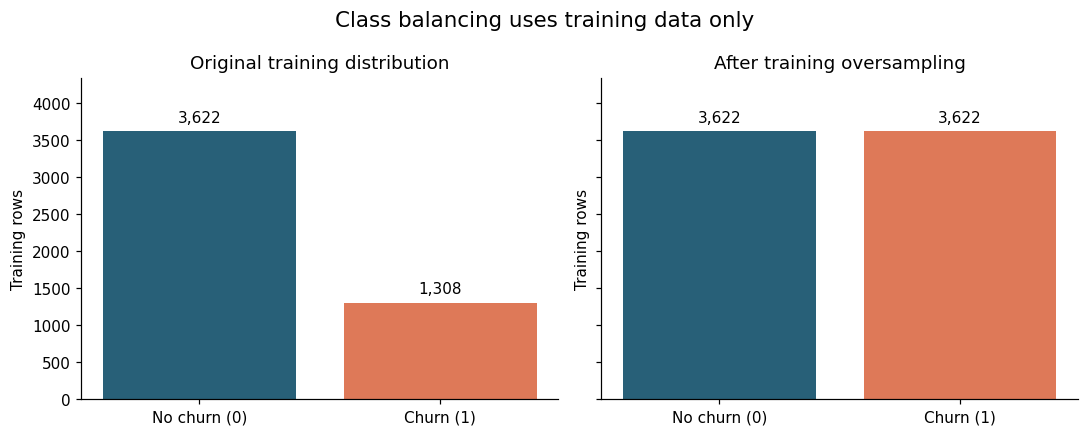

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, counts, title in zip(axes, [class_counts_before, class_counts_after],
                            ["Original training distribution", "After training oversampling"]):
    bars = ax.bar(["No churn (0)", "Churn (1)"], [counts.get(0, 0), counts.get(1, 0)],
                  color=[COLORS[0], COLORS[1]])
    ax.bar_label(bars, labels=[f"{int(value):,}" for value in [counts.get(0, 0), counts.get(1, 0)]], padding=4)
    ax.set_title(title)
    ax.set_ylim(0, majority_size * 1.2)
    ax.set_ylabel("Training rows")
fig.suptitle("Class balancing uses training data only", fontsize=14)
fig.tight_layout()
save_plot(fig, "04_class_balance.png")


## 12. Export reproducible artifacts

The **final clean dataset** for this midterm is `data/processed/train_clean.csv`.
The numeric and balanced variants document the encoding, scaling, and balancing exercises. The holdout
is retained separately as original raw records. `reports/preprocessing_parameters.json` records training
medians, means, scales, category sets, output column order, and fixed feature rules. Run this notebook to
reproduce the complete sequence. For future inference, use the same cleaning and feature rules, then
apply those saved training values without refitting on the holdout.


In [15]:
clean.to_csv(PROCESSED / "train_clean.csv", index=False)
model_ready.to_csv(PROCESSED / "train_model_ready.csv", index=False)
balanced.to_csv(PROCESSED / "train_balanced.csv", index=False)

parameters = {
    "imputation_medians": imputation_values,
    "numeric_imputation_columns": numeric_columns,
    "scaled_columns": standard_columns + power_columns,
    "pre_scaling_transform": {"TotalCharges": "square_root"},
    "scaling_means_after_reshaping": {key: float(value) for key, value in scaling_means.items()},
    "scaling_scales_after_reshaping_ddof0": {key: float(value) for key, value in scaling_scales.items()},
    "constant_numeric_columns": constant_numeric_columns,
    "one_hot_categories": category_levels,
    "one_hot_columns": one_hot_columns,
    "unseen_category_rule": "Reindex dummy columns to the saved training columns with fill_value=0",
    "feature_columns": feature_columns,
    "encoded_feature_names": encoded_feature_names,
    "binary_columns": binary_columns,
    "fixed_new_customer_threshold_months": 12,
    "service_count_yes_columns": service_yes_columns,
    "service_count_includes_internet": True,
    "missing_category": "Unknown",
    "target_mapping": {"No": 0, "Yes": 1},
    "random_seed": SEED,
}
(REPORTS / "preprocessing_parameters.json").write_text(json.dumps(parameters, indent=2), encoding="utf-8")
print("Saved clean, numeric, and balanced training CSVs, training-fitted parameters, and four plots.")


Saved clean, numeric, and balanced training CSVs, training-fitted parameters, and four plots.


## 13. Verify outputs and record results

Assertions below verify the split, target and ID exclusions, numeric completeness, class balance, and
unchanged source and holdout bytes. Exported training tables are read back to check their shapes and data types.
No holdout table is loaded for these checks. These checks validate data preparation, not model accuracy.


In [16]:
raw_hash_after = sha256_file(RAW)
train_hash_after = sha256_file(TRAIN_RAW)
holdout_hash_after = sha256_file(HOLDOUT_RAW)
assert raw_hash_after == source_hash_before, "Original dataset was modified."
assert train_hash_after == train_hash_before, "Raw training split was modified."
assert holdout_hash_after == holdout_hash_before, "Holdout split was modified."
assert clean.isna().sum().sum() == 0
assert len(clean) == split_counts["train"]
assert clean["customerID"].is_unique
assert "customerID" not in X_encoded.columns and "Churn" not in X_encoded.columns
assert np.isfinite(balanced.drop(columns=["customerID"]).to_numpy()).all()
assert list(model_ready.columns) == ["customerID", *encoded_feature_names, "Churn"]

for filename, expected in [("train_clean.csv", clean), ("train_model_ready.csv", model_ready),
                           ("train_balanced.csv", balanced)]:
    saved = pd.read_csv(PROCESSED / filename)
    assert saved.shape == expected.shape, f"Export shape mismatch: {filename}"
    assert saved.isna().sum().sum() == 0, f"Unexpected missing value: {filename}"
    if filename != "train_clean.csv":
        assert np.isfinite(saved.drop(columns=["customerID"]).to_numpy()).all()
    del saved

metrics = {
    "status": "Dataset approved 2026-09-27; final team review and contribution entries pending",
    "source_url": "https://www.kaggle.com/datasets/blastchar/telco-customer-churn",
    "source_rows": original_row_count,
    "source_columns": len(header),
    "source_schema": header,
    "seed": SEED,
    "split": {**split_counts, "requested_train_fraction": 0.7,
              "requested_test_fraction": 0.3, "stratified_on": "Churn",
              "algorithm": "NumPy random generator; largest-remainder class allocation",
              "customer_ids_disjoint": split_id_disjoint},
    "training_exact_duplicate_records": exact_duplicate_count,
    "training_repeated_profiles_excluding_id": duplicate_profile_count,
    "training_raw_blank_counts": {key: int(value) for key, value in raw_blank_counts.items()},
    "training_numeric_missing_before_imputation": {key: int(value) for key, value in numeric_missing_before.items()},
    "training_unparseable_nonblank_numeric_counts": invalid_numeric_counts,
    "training_negative_numeric_counts": negative_numeric_counts,
    "training_categorical_blank_counts": categorical_blank_counts,
    "imputation_medians": imputation_values,
    "training_class_counts_before": {str(key): int(value) for key, value in class_counts_before.items()},
    "training_class_counts_after": {str(key): int(value) for key, value in class_counts_after.items()},
    "training_churn_rate": float(target.mean()),
    "balanced_training_rows": len(balanced),
    "added_oversampled_rows": len(balanced) - len(model_ready),
    "input_predictor_count": len(feature_columns),
    "encoded_predictor_count": len(encoded_feature_names),
    "one_hot_column_count": len(one_hot_columns),
    "total_charges_transform": "square_root_then_standard_scaling",
    "total_charges_skew_before_on_imputed_rows": skew_before,
    "total_charges_skew_after": skew_after,
    "total_charges_absolute_skew_decreased": bool(skew_improved),
    "contract_churn_training": contract_summary.reset_index().to_dict(orient="records"),
    "output_shapes": {"train_clean": list(clean.shape), "train_model_ready": list(model_ready.shape),
                      "train_balanced": list(balanced.shape)},
    "integrity": {
        "source_sha256_before": source_hash_before, "source_sha256_after": raw_hash_after,
        "train_raw_sha256_before": train_hash_before, "train_raw_sha256_after": train_hash_after,
        "holdout_sha256_before": holdout_hash_before, "holdout_sha256_after": holdout_hash_after,
        "original_source_unchanged": source_hash_before == raw_hash_after,
        "raw_training_unchanged": train_hash_before == train_hash_after,
        "holdout_unchanged": holdout_hash_before == holdout_hash_after,
        "holdout_eda_performed": False, "holdout_preprocessed": False, "holdout_evaluated": False,
    },
    "software_versions": {"python": platform.python_version(), "numpy": np.__version__,
                          "pandas": pd.__version__, "matplotlib": matplotlib.__version__},
    "model_training_performed": False,
    "checks_passed": True,
}
(REPORTS / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print("All preparation checks passed. Original source, raw training split, and raw holdout hashes are unchanged.")
print(f"Clean training table: {clean.shape[0]:,} rows x {clean.shape[1]} columns.")
print(f"Numeric training table: {model_ready.shape[0]:,} rows, {len(encoded_feature_names)} predictors + ID + target.")
print(f"Balanced training table: {len(balanced):,} rows, {majority_size:,} per class.")
print("No model was trained and no testing performance was calculated.")


All preparation checks passed. Original source, raw training split, and raw holdout hashes are unchanged.
Clean training table: 4,930 rows x 25 columns.
Numeric training table: 4,930 rows, 49 predictors + ID + target.
Balanced training table: 7,244 rows, 3,622 per class.
No model was trained and no testing performance was calculated.


## 14. What this prepares us to do in the final project

**ML problem:** Binary classification of customer churn. Compare a majority-class baseline, logistic regression,
and one or more tree-based models. Define when a prediction is made and verify that all predictors would
be known at that time; this historical sample does not supply a prospective validation design.

**Validation:** Use stratified cross-validation only within the original training split. Refit preprocessing
and any oversampling inside each fold, then compare class weights, oversampling, and natural prevalence.
Use precision, recall, F1, ROC-AUC, and especially precision–recall performance alongside a confusion matrix;
plain accuracy can disguise poor detection of the minority class. Choose thresholds from training validation
with an explicit business tradeoff. No validation or test scores are invented in this notebook.

**Final evaluation:** After model/feature/threshold selection is complete, refit on all original training rows,
apply the fixed cleaning and fitted transformation sequence to the sealed holdout, and evaluate once at its
natural class prevalence. Never oversample the holdout. That future step is outside this EDA submission.

**Limitations and reflection:** Median imputation is an approximation; engineered features may be redundant;
the square-root transform may not benefit every model; oversampling repeats information; and a sample from one
context may not generalize. Customer demographics warrant group-level error checks before any real use.
The team should discuss the generated results in its own words, record actual contributions, verify the source,
and follow its course policy on AI assistance before final submission.


## Team review — comparing the submitted approaches

**Viviana Zamora / Patrick Ray — approved main workflow:** The executed notebook above uses a stratified 70/30 train/holdout split before training-only exploration, training-median imputation of `TotalCharges`, one-hot encoding, scaling, engineered features, and a separate random-oversampled training copy. Patrick independently executed and checked this notebook and organized the artifacts. The original test partition is not used to choose preprocessing decisions.

**Funsho Orogun — alternative exploratory workflow:** Funsho's submitted `Midterm_Notebook.ipynb` demonstrates conversion of `TotalCharges`, categorical encoding, `StandardScaler`, and SMOTE. Its reported balanced data have 10,348 rows and 30 feature columns. His accompanying discussion proposes an 80/20 split *after* balancing. This is presented as a **comparison only**, not merged into the approved workflow: applying SMOTE before a train/test split risks having synthetic information from training examples influence the evaluation partition. A future fair comparison would split first, then fit transformations and apply SMOTE only inside training folds. Funsho's original notebook is retained as separate team work.

**Dustin Mastrota — technical review:** Dustin's analysis documents why the main workflow uses a 70/30 split, preserves the test partition, imputes eight training-set `TotalCharges` values with a median of 1,415.275, encodes categorical predictors, engineers features, scales numeric variables, and demonstrates balancing with a separate training copy. He identifies limitations of median imputation, repeated oversampling, and the fact that preprocessing alone does not establish predictive accuracy. Dustin's submitted analysis, reflection, and contribution journal are separate supporting documents.

**Reconciliation:** The main reproducible notebook above is the canonical workflow for the midterm because it follows the approved proposal. Funsho's code is not executed in the canonical pipeline and his alternative numeric results must not be presented as outputs of that pipeline. Team contribution statements are documented separately; authorship of particular cells should not be inferred solely from this consolidation.

### Future machine-learning use

The team can compare logistic regression and tree-based classifiers on the untouched holdout only after selecting models with training-only validation. Imputation, encoding, scaling, and any resampling must be fitted within training folds to avoid leakage. Suitable evaluation metrics include precision, recall, F1, ROC-AUC, and precision–recall measures.
